In [1]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    print(dirname)
    for filename in filenames[:5]:
        print("  ", filename)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/deadskull7
/kaggle/input/datasets/deadskull7/fer2013
   fer2013.csv


In [2]:
RAW_DATA_PATH = "/kaggle/input/datasets/deadskull7/fer2013/fer2013.csv"
PROCESSED_DIR = "/kaggle/working/processed"
FIGURES_DIR = "/kaggle/working/figures"
MODELS_DIR = "/kaggle/working/models"

In [3]:
import os
import pandas as pd

print(os.path.exists(RAW_DATA_PATH))

df = pd.read_csv(RAW_DATA_PATH)
print(df.shape)
print(df.head())

True
(35887, 3)
   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training


In [4]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm

RAW_DATA_PATH = "/kaggle/input/datasets/deadskull7/fer2013/fer2013.csv"
PROCESSED_DIR = "/kaggle/working/processed"
FIGURES_DIR = "/kaggle/working/figures"
MODELS_DIR = "/kaggle/working/models"

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

EMOTIONS = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

df = pd.read_csv(RAW_DATA_PATH)

def save_fer2013_images(df, output_root):
    for usage in ["Training", "PublicTest", "PrivateTest"]:
        subset = df[df["Usage"] == usage]
        print(f"Processing {usage}: {len(subset)} images")

        for idx, row in tqdm(subset.iterrows(), total=len(subset)):
            emotion_name = EMOTIONS[row["emotion"]]
            output_dir = os.path.join(output_root, usage, emotion_name)
            os.makedirs(output_dir, exist_ok=True)

            pixels = np.array(row["pixels"].split(), dtype=np.uint8).reshape(48, 48)
            img = Image.fromarray(pixels).convert("RGB")
            img = img.resize((224, 224))

            output_path = os.path.join(output_dir, f"{idx}.png")
            img.save(output_path)

save_fer2013_images(df, PROCESSED_DIR)

Processing Training: 28709 images


100%|██████████| 28709/28709 [04:44<00:00, 101.03it/s]


Processing PublicTest: 3589 images


100%|██████████| 3589/3589 [00:35<00:00, 101.04it/s]


Processing PrivateTest: 3589 images


100%|██████████| 3589/3589 [00:35<00:00, 101.02it/s]


In [5]:
TRAIN_DIR = "/kaggle/working/processed/Training"
VAL_DIR = "/kaggle/working/processed/PublicTest"
TEST_DIR = "/kaggle/working/processed/PrivateTest"

In [7]:
import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V2_Weights

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [8]:
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)

Using device: cuda


In [9]:
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
import os

TRAIN_DIR = "/kaggle/working/processed/Training"
VAL_DIR = "/kaggle/working/processed/PublicTest"
TEST_DIR = "/kaggle/working/processed/PrivateTest"

for path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(path)
    print("Exists:", os.path.exists(path))
    if os.path.exists(path):
        print("Folders:", os.listdir(path))
    print()

/kaggle/working/processed/Training
Exists: True
Folders: ['Surprise', 'Neutral', 'Happy', 'Disgust', 'Angry', 'Fear', 'Sad']

/kaggle/working/processed/PublicTest
Exists: True
Folders: ['Surprise', 'Neutral', 'Happy', 'Disgust', 'Angry', 'Fear', 'Sad']

/kaggle/working/processed/PrivateTest
Exists: True
Folders: ['Surprise', 'Neutral', 'Happy', 'Disgust', 'Angry', 'Fear', 'Sad']



In [11]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds = datasets.ImageFolder(VAL_DIR, transform=eval_tf)
test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_tf)

print("Classes:", train_ds.classes)
print("Train size:", len(train_ds))
print("Validation size:", len(val_ds))
print("Test size:", len(test_ds))
print("Class to index:", train_ds.class_to_idx)

Classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
Train size: 28709
Validation size: 3589
Test size: 3589
Class to index: {'Angry': 0, 'Disgust': 1, 'Fear': 2, 'Happy': 3, 'Neutral': 4, 'Sad': 5, 'Surprise': 6}


In [12]:
#Create DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [13]:
#Compute class weights
targets = np.array(train_ds.targets)
class_counts = np.bincount(targets)

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

for cls, count, weight in zip(train_ds.classes, class_counts, class_weights.cpu().numpy()):
    print(f"{cls:10s} count={count:5d} weight={weight:.4f}")

Angry      count= 3995 weight=0.0686
Disgust    count=  436 weight=0.6283
Fear       count= 4097 weight=0.0669
Happy      count= 7215 weight=0.0380
Neutral    count= 4965 weight=0.0552
Sad        count= 4830 weight=0.0567
Surprise   count= 3171 weight=0.0864


In [14]:
#Build MobileNetV2 model
weights = MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)

# Replace ImageNet classifier with FER2013 classifier
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)

model = model.to(DEVICE)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=7, bias=True)
)


In [15]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

In [16]:
#Training and validation functions
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

In [17]:
#Do a short test run first
EPOCHS = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

start = time.time()

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE
    )

    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f}, acc {val_acc:.4f}"
    )

end = time.time()
print(f"Training time: {(end - start)/60:.2f} minutes")

Epoch 1/10 | train loss 1.5142, acc 0.4335 | val loss 1.2327, acc 0.5339
Epoch 2/10 | train loss 1.1548, acc 0.5669 | val loss 1.1075, acc 0.5729
Epoch 3/10 | train loss 1.0146, acc 0.6114 | val loss 1.0329, acc 0.6105
Epoch 4/10 | train loss 0.9449, acc 0.6359 | val loss 1.0093, acc 0.6225
Epoch 5/10 | train loss 0.8603, acc 0.6635 | val loss 0.9834, acc 0.6325
Epoch 6/10 | train loss 0.7848, acc 0.6932 | val loss 0.9555, acc 0.6450
Epoch 7/10 | train loss 0.7374, acc 0.7081 | val loss 0.9356, acc 0.6542
Epoch 8/10 | train loss 0.7035, acc 0.7225 | val loss 0.9477, acc 0.6551
Epoch 9/10 | train loss 0.6640, acc 0.7334 | val loss 0.9405, acc 0.6615
Epoch 10/10 | train loss 0.6319, acc 0.7522 | val loss 0.9566, acc 0.6590
Training time: 36.11 minutes


In [18]:
EPOCHS_EXTRA = 5

for epoch in range(EPOCHS_EXTRA):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE
    )

    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(
        f"Extra Epoch {epoch+1}/{EPOCHS_EXTRA} | "
        f"train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f}, acc {val_acc:.4f}"
    )

print("Best validation accuracy:", best_val_acc)

Extra Epoch 1/5 | train loss 0.5849, acc 0.7663 | val loss 0.9520, acc 0.6609
Extra Epoch 2/5 | train loss 0.5630, acc 0.7792 | val loss 0.9550, acc 0.6684
Extra Epoch 3/5 | train loss 0.5450, acc 0.7842 | val loss 0.9645, acc 0.6637
Extra Epoch 4/5 | train loss 0.5309, acc 0.7897 | val loss 0.9745, acc 0.6617
Extra Epoch 5/5 | train loss 0.5090, acc 0.7987 | val loss 0.9902, acc 0.6715
Best validation accuracy: 0.6714962385065478


In [22]:
import os
import torch

MODELS_DIR = "/kaggle/working/models"
os.makedirs(MODELS_DIR, exist_ok=True)

# Load the best validation model weights
model.load_state_dict(best_model_wts)

pth_path = os.path.join(MODELS_DIR, "emotion_mobilenet.pth")

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": train_ds.classes,
    "class_to_idx": train_ds.class_to_idx,
    "val_acc": best_val_acc,
    "history": history
}, pth_path)

print("Saved model to:", pth_path)
print("Best validation accuracy:", best_val_acc)

Saved model to: /kaggle/working/models/emotion_mobilenet.pth
Best validation accuracy: 0.6714962385065478


In [24]:
import os

FIGURES_DIR = "/kaggle/working/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

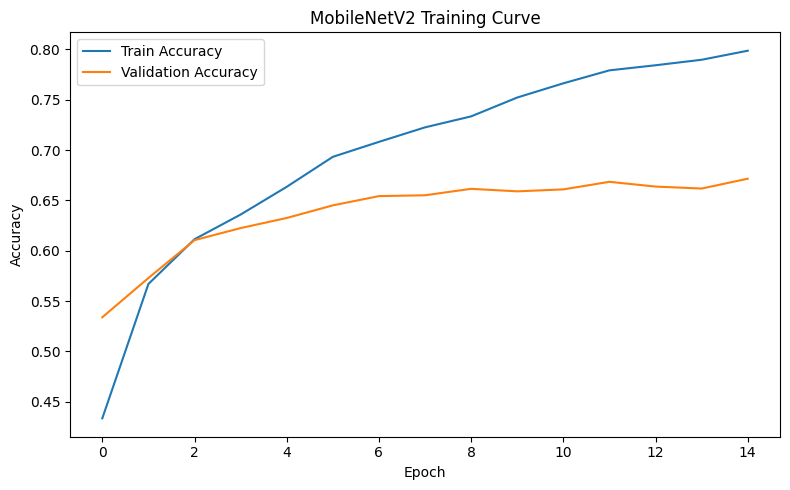

Saved: /kaggle/working/figures/training_curves_mobilenet.png


In [25]:
#Plot training curves

import os
import matplotlib.pyplot as plt

FIGURES_DIR = "/kaggle/working/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training Curve")
plt.legend()
plt.tight_layout()

curve_path = os.path.join(FIGURES_DIR, "training_curves_mobilenet.png")
plt.savefig(curve_path, dpi=150)
plt.show()

print("Saved:", curve_path)

In [26]:
#Evaluate on validation set
val_loss, val_acc, val_preds, val_labels = evaluate(
    model, val_loader, criterion, DEVICE
)

print("Validation loss:", val_loss)
print("Validation accuracy:", val_acc)

Validation loss: 0.9902197103475122
Validation accuracy: 0.6714962385065478


In [27]:
report = classification_report(
    val_labels,
    val_preds,
    target_names=train_ds.classes,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
Angry,0.577154,0.616702,0.596273,467.000000
Disgust,0.716981,0.678571,0.697248,56.000000
Fear,0.534442,0.453629,0.490731,496.000000
Happy,0.879070,0.844693,0.861538,895.000000
Neutral,0.612800,0.630972,0.621753,607.000000
Sad,0.555556,0.574273,0.564759,653.000000
Surprise,0.756579,0.831325,0.792193,415.000000
accuracy,0.671496,0.671496,0.671496,0.671496
macro avg,0.661797,0.661452,0.660642,3589.000000
weighted avg,0.671569,0.671496,0.670643,3589.000000


In [28]:
report_path = os.path.join(FIGURES_DIR, "classification_report_mobilenet.csv")
report_df.to_csv(report_path)
print("Saved:", report_path)

Saved: /kaggle/working/figures/classification_report_mobilenet.csv


<Figure size 800x800 with 0 Axes>

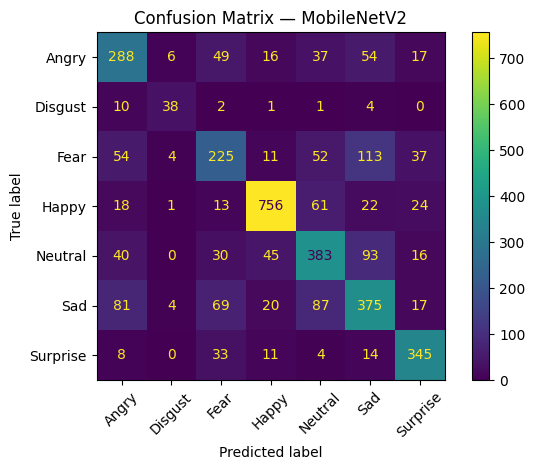

Saved: /kaggle/working/figures/confusion_matrix_mobilenet.png


In [29]:
##Confusion matrix
cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_ds.classes
)
disp.plot(values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix — MobileNetV2")
plt.tight_layout()

cm_path = os.path.join(FIGURES_DIR, "confusion_matrix_mobilenet.png")
plt.savefig(cm_path, dpi=150)
plt.show()

print("Saved:", cm_path)

In [30]:
#Export to ONNX
model.eval()
model = model.to("cpu")

dummy_input = torch.randn(1, 3, 224, 224)

onnx_path = os.path.join(MODELS_DIR, "emotion_model.onnx")

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    },
    opset_version=11
)

print("Exported ONNX model to:", onnx_path)


/tmp/ipykernel_283/3300229301.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0519 12:27:01.087000 283 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0519 12:27:01.828000 283 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1,

[torch.onnx] Obtain model graph for `MobileNetV2([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV2([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Exported ONNX model to: /kaggle/working/models/emotion_model.onnx


In [31]:
#Test ONNX model loads
import os
import onnxruntime as ort

onnx_path = "/kaggle/working/models/emotion_model.onnx"

print("ONNX file exists:", os.path.exists(onnx_path))
print("ONNX file size:", os.path.getsize(onnx_path) / (1024 * 1024), "MB")

sess = ort.InferenceSession(onnx_path)

print("ONNX inputs:")
for inp in sess.get_inputs():
    print(inp.name, inp.shape, inp.type)

print("ONNX outputs:")
for out in sess.get_outputs():
    print(out.name, out.shape, out.type)

ONNX file exists: True
ONNX file size: 0.2414989471435547 MB
ONNX inputs:
input ['batch_size', 3, 224, 224] tensor(float)
ONNX outputs:
output ['batch_size', 7] tensor(float)


In [32]:
import numpy as np

sample_img, sample_label = val_ds[0]
sample_input = sample_img.unsqueeze(0).numpy().astype(np.float32)

outputs = sess.run(None, {"input": sample_input})
pred_idx = outputs[0].argmax(axis=1)[0]

print("True label:", train_ds.classes[sample_label])
print("Predicted:", train_ds.classes[pred_idx])
print("Output shape:", outputs[0].shape)

True label: Angry
Predicted: Sad
Output shape: (1, 7)


In [33]:
import numpy as np

sample_img, sample_label = val_ds[0]
sample_input = sample_img.unsqueeze(0).numpy().astype(np.float32)

outputs = sess.run(None, {"input": sample_input})
logits = outputs[0][0]

probs = np.exp(logits) / np.exp(logits).sum()

for cls, prob in zip(train_ds.classes, probs):
    print(f"{cls:10s}: {prob:.4f}")

pred_idx = probs.argmax()

print("\nTrue label:", train_ds.classes[sample_label])
print("Predicted:", train_ds.classes[pred_idx])
print("Confidence:", probs[pred_idx])

Angry     : 0.3877
Disgust   : 0.0068
Fear      : 0.0279
Happy     : 0.0053
Neutral   : 0.0632
Sad       : 0.5085
Surprise  : 0.0006

True label: Angry
Predicted: Sad
Confidence: 0.50852394


In [34]:
import torch
import numpy as np

sample_img, sample_label = val_ds[0]
sample_batch = sample_img.unsqueeze(0)

# PyTorch prediction
model.eval()
with torch.no_grad():
    torch_logits = model(sample_batch)
    torch_probs = torch.softmax(torch_logits, dim=1).numpy()[0]
    torch_pred = torch_probs.argmax()

# ONNX prediction
onnx_input = sample_batch.numpy().astype(np.float32)
onnx_logits = sess.run(None, {"input": onnx_input})[0][0]
onnx_probs = np.exp(onnx_logits) / np.exp(onnx_logits).sum()
onnx_pred = onnx_probs.argmax()

print("True label:", train_ds.classes[sample_label])
print("PyTorch predicted:", train_ds.classes[torch_pred], torch_probs[torch_pred])
print("ONNX predicted:", train_ds.classes[onnx_pred], onnx_probs[onnx_pred])

True label: Angry
PyTorch predicted: Sad 0.5085215
ONNX predicted: Sad 0.50852394


In [35]:
correct = 0
total = 0

for imgs, labels in val_loader:
    imgs_np = imgs.numpy().astype(np.float32)
    outputs = sess.run(None, {"input": imgs_np})[0]
    preds = outputs.argmax(axis=1)

    correct += (preds == labels.numpy()).sum()
    total += labels.size(0)

onnx_acc = correct / total
print("ONNX validation accuracy:", onnx_acc)

ONNX validation accuracy: 0.6714962385065478


In [36]:
!zip -r stage3_outputs.zip /kaggle/working/models /kaggle/working/figures

  adding: kaggle/working/models/ (stored 0%)
  adding: kaggle/working/models/emotion_model.onnx.data (deflated 8%)
  adding: kaggle/working/models/emotion_model.onnx (deflated 93%)
  adding: kaggle/working/models/emotion_mobilenet.pth (deflated 8%)
  adding: kaggle/working/figures/ (stored 0%)
  adding: kaggle/working/figures/classification_report_mobilenet.csv (deflated 46%)
  adding: kaggle/working/figures/confusion_matrix_mobilenet.png (deflated 8%)
  adding: kaggle/working/figures/training_curves_mobilenet.png (deflated 11%)
